<a href="https://colab.research.google.com/github/elhamod/BA305_Fall_2026/blob/main/Session%2010%20-%20MAKEUP%20FRI%20OCT%202%20-%20EXAM%201%20PREP/exam1_practice_auto_mpg_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exam 1 Practice: Auto MPG — Solutions**

*Worked solutions. Try `exam1_practice_auto_mpg.ipynb` first, then compare your answers here.*

You work for a used-car website. Sellers often leave fields blank on the listing form. The team has three questions:

1. Can we **shorten the form**?
2. Can we **estimate a missing mpg**?
3. Can we **tag a car "Imported" or "Domestic"** automatically?

**Practice, not graded.** Use Colab's AI for the code. Write the one-sentence answers yourself: on the exam you read output, you don't run code.

| Part | Topic | Time |
| --- | --- | --- |
| 1 | Cleaning and charts | ~15 min |
| 2 | Fewer dimensions | ~13 min |
| 3 | Regression | ~16 min |
| 4 | Classification | ~26 min |

**Data:** Auto MPG, 398 cars from 1970–1982.

## Setup

In [1]:
# Import the libraries this notebook uses.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Load the Auto MPG data: one row per car model.
cars = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv')
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


# **Part 1: Know your data** (~15 min)

### Clean the data

**Exercise 1.** Look at every column. Decide which ones a model can use as they are, which need fixing, and which should be dropped. Then clean the data.

In [3]:
# Check each column's type and count its missing values.
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 35.9 KB


In [4]:
# Show the cars with no horsepower recorded.
cars[cars['horsepower'].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,usa,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,europe,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,europe,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,usa,amc concord dl


In [5]:
# Drop the cars with missing horsepower and the name column, then renumber the rows.
cars = cars.dropna().drop(columns=['name']).reset_index(drop=True)
print('Cars left:', len(cars))
cars['origin'].value_counts()

Cars left: 392


origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

**Question 1.** Which columns did you keep, fix or drop, and why? How many cars are left?

**Answer**

- **Missing values:** 6 cars have no `horsepower`, which is 1.5% of the data. Dropping them costs little. Models cannot take a blank, and filling the gap with an average would invent a horsepower for, say, a Renault.
- **Identifier:** `name` is different for almost every car. It describes nothing a model can learn from, so drop it.
- **Category:** `origin` is text with three levels (usa, japan, europe). It has to become **dummy columns** before a model can use it (Exercise 5). It must not become the numbers 1/2/3, which would imply Europe sits "between" the USA and Japan.
- **Cost:** 392 of 398 cars remain.

### Check a claim

Sales says: *"Imported cars get better mileage."*

**Exercise 2.**
1. Compare the average mpg of imported and domestic cars. Does it back the claim?
2. Weight also affects mileage. Plot mpg against weight, colored by origin. Then compare the average mpg by origin for light cars only (under 2,500 lb).

In [6]:
# The sales team's evidence: average mpg and weight by origin.
cars.groupby('origin')[['mpg', 'weight']].mean().round(0)

,mpg,weight
origin,,
europe,28.0,2433.0
japan,30.0,2221.0
usa,20.0,3372.0


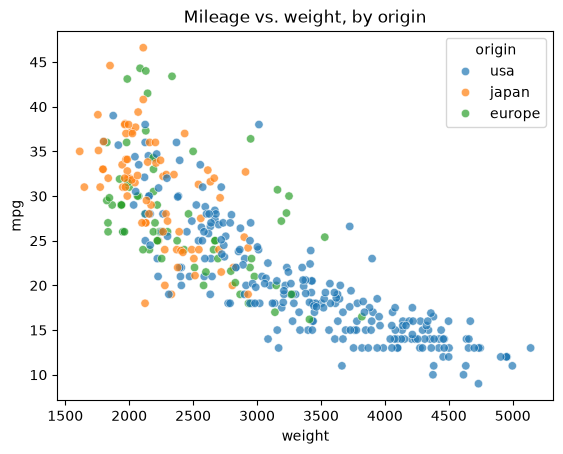

In [7]:
# Plot mileage against weight, colored by origin.
sns.scatterplot(data=cars, x='weight', y='mpg', hue='origin', alpha=0.7)
plt.title('Mileage vs. weight, by origin');

In [8]:
# Compare like with like: average mpg by origin for light cars only (under 2,500 lb).
light_cars = cars[cars['weight'] < 2500]
light_cars.groupby('origin')['mpg'].mean().round(1)

origin
europe    30.2
japan     31.7
usa       29.1
Name: mpg, dtype: float64

**Question 2.** Is being imported the real cause of better mileage, or is it something else? What does the relationship with weight suggest?

**Answer**

The table supports the ad: imports average about 28–30 mpg against 20 for domestic cars. But imports are also **about 1,000 lb lighter**. In the scatter, mileage falls steeply with weight, and at the same weight the colors overlap. The light-car table shows it: under 2,500 lb, US cars get 29.1 mpg against 30.2 and 31.7 for imports. In the scatter, almost every car over 3,000 lb is American, so "import" is mostly standing in for "light car" (**confounding**).

The honest ad is "light cars save fuel", not "imports save fuel". Keep one more thing from this chart for later: the mpg–weight relationship is a **curve**, not a straight line. That matters in Exercise 6.

# **Part 2: Do we need all six specs?** (~13 min)

The form asks for six specs: cylinders, displacement, horsepower, weight, acceleration and mpg. If some say the same thing, we can ask for fewer.

In [9]:
# The six specs the listing form asks for.
specs = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'mpg']

### How much repeats?

**Exercise 3.** Look at how the six specs relate to each other. Then find a way to describe each car with fewer numbers while losing as little information as possible.

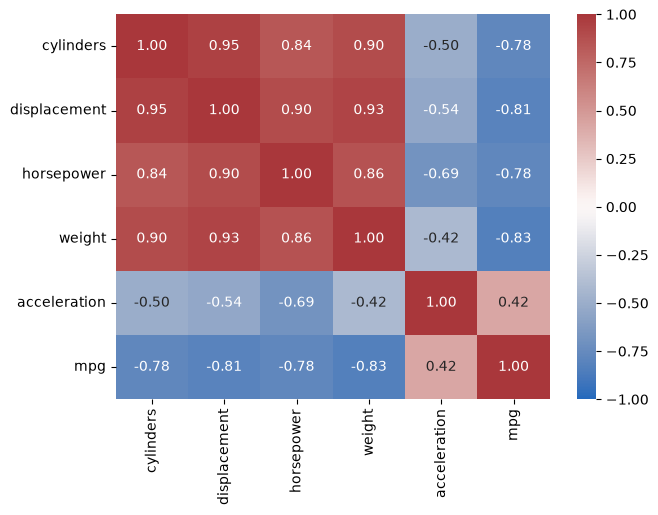

In [10]:
# Correlation of each spec with every other spec.
plt.figure(figsize=(7, 5))
sns.heatmap(cars[specs].corr(), annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='vlag');

In [11]:
# Scale the six specs, then run PCA on them.
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(cars[specs]), columns=specs)

pcs = PCA()
pc_names = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']
scores_df = pd.DataFrame(pcs.fit_transform(scaled_df), columns=pc_names)

# Share of the total variation carried by each component.
pd.DataFrame({'% of variance': pcs.explained_variance_ratio_ * 100,
              'Cumulative %': np.cumsum(pcs.explained_variance_ratio_) * 100},
             index=pc_names).round(1)

,% of variance,Cumulative %
PC1,79.8,79.8
PC2,12.1,91.9
PC3,4.3,96.3
PC4,2.1,98.3
PC5,1.1,99.4
PC6,0.6,100.0


**Question 3.** Which specs move together? How many new dimensions do you need to keep about 85% of the variation?

**Answer**

Cylinders, displacement, horsepower and weight correlate with each other at **0.84–0.95**, so they move almost as one. **mpg** moves against all four (−0.78 to −0.83): bigger, more powerful cars burn more fuel. Acceleration is the loosest fit (−0.42 to −0.69).

The tool for "fewer numbers, little information lost" is **PCA**, run on the **scaled** specs.

**PC1 alone carries 80%** of the variation, just short of 85%, so it takes **2 dimensions (92%)**. Three carry 96%. The six questions on the form contain only about **two** independent ideas.

### What are the ideas?

**Exercise 4.** Interpret the new dimensions: what does each of the first three measure?

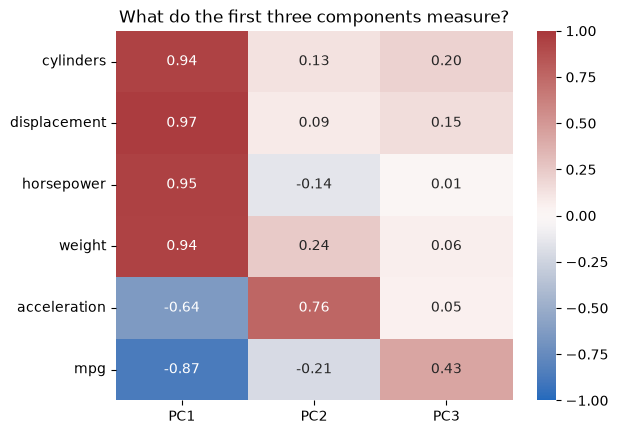

In [12]:
# Component matrix: correlation of each spec with each component (as in Lab 2).
loadings_df = pd.concat([scores_df, scaled_df], axis=1).corr().loc[specs, pc_names]
sns.heatmap(loadings_df[['PC1', 'PC2', 'PC3']], annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='vlag')
plt.title('What do the first three components measure?');

**Question 4.** Give each of the first three new dimensions a plain-English name. Which original specs drive each one?

**Answer**

- **PC1, "big, powerful and thirsty":** cylinders, displacement, horsepower and weight all correlate above 0.9 with it, and mpg runs the other way (−0.87). One number captures a car's size and its fuel use together.
- **PC2, "sluggishness":** mostly acceleration (0.76). Acceleration is seconds to 60 mph, so a high value means a slow car. It is the one spec that is not just "size".
- **PC3, "mileage beyond what size explains":** mostly mpg (0.43). It is only 4% of the variation, so do not over-read it: it marks cars that are more (or less) efficient than their size would suggest.

So the four engine questions, and largely mpg too, repeat one another.

# **Part 3: Estimate mpg** (~16 min)

Many listings have no mpg. We want to show an estimate, but only if it is close enough.

### How far off is the estimate?

**Exercise 5.** Predict mpg from the other five specs and origin. Compute the test RMSE of two approaches: an average guess and linear regression. Then compute R² for each.

In [13]:
# Predictors: the five other specs plus origin as dummy columns. Target: mpg.
X = pd.get_dummies(cars[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'origin']])
y = cars['mpg']

# Hold out 30% of the cars as a test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [14]:
# (i) Naive guess: every test car gets the training cars' average mpg.
naive = np.full(len(y_test), y_train.mean())
print('Naive guess RMSE:      ', round(np.sqrt(mean_squared_error(y_test, naive)), 2))

# (ii) Linear regression.
lin = LinearRegression().fit(X_train, y_train)
print('Linear regression RMSE:', round(np.sqrt(mean_squared_error(y_test, lin.predict(X_test))), 2))

Naive guess RMSE:       8.15
Linear regression RMSE: 4.25


In [15]:
# R²: the share of the variation in mpg that each approach explains (1 = perfect, 0 = no better than the average).
print('Naive guess R²:      ', round(r2_score(y_test, naive), 2))
print('Linear regression R²:', round(r2_score(y_test, lin.predict(X_test)), 2))

Naive guess R²:       -0.0
Linear regression R²: 0.73


**Question 5.** Finish the sentence: *"A typical estimate is off by about ___ mpg."* What does R² tell you that RMSE does not?

**Answer**

| Approach | Test RMSE (mpg) | R² |
| --- | --- | --- |
| Average guess | 8.15 | about 0 |
| Linear regression | 4.25 | 0.73 |

Linear regression roughly halves the error of the average guess.

For the product team: *"A typical estimate is off by about 4 mpg, compared with about 8 if we just showed the average."* Whether that is good enough is a business call. For a 20-mpg car, 4 mpg is a 20% error, so the listing should say "estimated".

**R²** puts the result on a 0-to-1 scale. Linear regression explains **73%** of the variation in mpg, and the average guess explains about **0%**. That is R²'s definition of "no better than the average". It shows as −0.0 because the average came from the training cars, not the test cars. R² answers *how much of the pattern did we capture?*, and RMSE answers *how far off is a typical estimate, in mpg?* The team needs RMSE to decide what to show buyers. "73%" says nothing about whether a 4-mpg miss is acceptable.

### Can we trust that number?

**Exercise 6.** Estimate linear regression's RMSE with 5-fold cross-validation.

In [16]:
# 5-fold cross-validation: every car sits in a test fold exactly once.
# sklearn reports errors as negative scores, so we flip the sign back.
folds = KFold(n_splits=5, shuffle=True, random_state=0)

lin_rmse = -cross_val_score(LinearRegression(), X, y, scoring='neg_root_mean_squared_error', cv=folds)
print('Linear regression RMSE per fold:', lin_rmse.round(2), ' mean:', round(lin_rmse.mean(), 2), ' std:', round(lin_rmse.std(), 2))

Linear regression RMSE per fold: [4.13 4.38 4.25 4.38 4.02]  mean: 4.23  std: 0.14


**Question 6.** How much does the RMSE change from fold to fold? Which number would you quote to the team, and why?

**Answer**

Across the five folds the RMSE runs from **4.02 to 4.38**. That spread of about 0.4 mpg comes only from which cars happened to land in the test fold, so the single split in Exercise 5 (4.25) was one draw among many.

Quote the cross-validated average, **4.23 ± 0.14 mpg (about 4.2)**. It rests on all 392 cars instead of one draw of 118, and the ± tells the team how much it could move.

# **Part 4: Tag imports** (~26 min)

Buyers filter by "Imported". If an import is tagged "Domestic", those buyers never see it. Can the specs predict the tag?

### Better than guessing?

**Exercise 7.** Find the share of imported cars. Then choose k for kNN with cross-validation.

*New tool:* `make_pipeline(StandardScaler(), model)` scales inside each fold, so the test fold never leaks into the scaling.

In [17]:
# Target: 1 = imported, 0 = domestic. Predictors: the six specs.
y_imp = (cars['origin'] != 'usa').astype(int)
X_specs = cars[specs]
print('Share of cars imported:', round(y_imp.mean(), 3))

Share of cars imported: 0.375


,k,accuracy
8,9,0.847
4,5,0.847
14,15,0.842


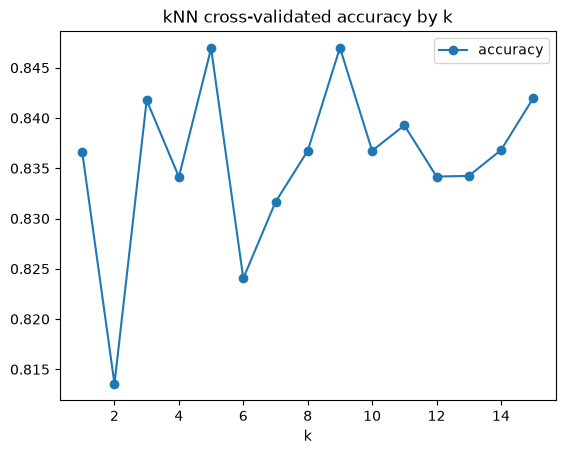

In [18]:
# Cross-validated accuracy of kNN for every k from 1 to 15 (scaling re-learned inside each fold).
results = []
for k in range(1, 16):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    results.append({'k': k, 'accuracy': cross_val_score(model, X_specs, y_imp, scoring='accuracy', cv=folds).mean()})

results_df = pd.DataFrame(results)
results_df.plot(x='k', y='accuracy', marker='o', title='kNN cross-validated accuracy by k')
results_df.sort_values('accuracy', ascending=False).head(3).round(3)

**Question 7.** How accurate is calling every car "Domestic"? Which k do you pick, and how much better than that baseline is kNN?

**Answer**

1. **Baseline:** 37.5% of cars are imported, so tagging everything "Domestic" is **62.5% accurate** and catches **zero** imports. Accuracy alone would make that sound respectable.
2. **kNN:** cross-validated accuracy is fairly flat across k, peaking at about **0.85 at k = 5 or 9**. That is about 22 points above the baseline, so the specs really do carry the import signal.

### Precision vs. recall

The code below is **given**: run it. It builds a second classifier, **logistic regression**, which gives every car a *probability* of being imported. It is fitted on a training split, so its mistakes can be checked on the held-out test cars.

In [19]:
# Given: the target (1 = imported) and the six specs, set up here so this cell runs on its own.
data = cars.dropna()
X_specs = data[specs]
y_imp = (data['origin'] != 'usa').astype(int)

# Given: logistic regression, fitted on a training split; the test cars are held out for Exercise 8.
X_train, X_test, y_train, y_test = train_test_split(X_specs, y_imp, test_size=0.3, random_state=1, stratify=y_imp)
logit = make_pipeline(StandardScaler(), LogisticRegression())
logit.fit(X_train, y_train);

**Exercise 8.** Show the confusion matrix of the logistic regression above on the test cars. Then find the probability cutoff that best balances the two types of error (the highest F1 score).

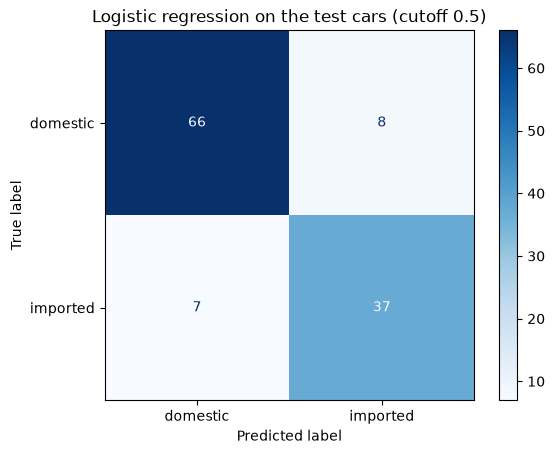

In [20]:
# Confusion matrix of the given logistic regression on the held-out test cars.
y_pred = logit.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['domestic', 'imported'], cmap='Blues')
plt.title('Logistic regression on the test cars (cutoff 0.5)')
plt.show()

,cutoff,precision,recall,F1
8,0.45,0.82,0.91,0.86
6,0.35,0.77,0.98,0.86
7,0.40,0.77,0.93,0.85


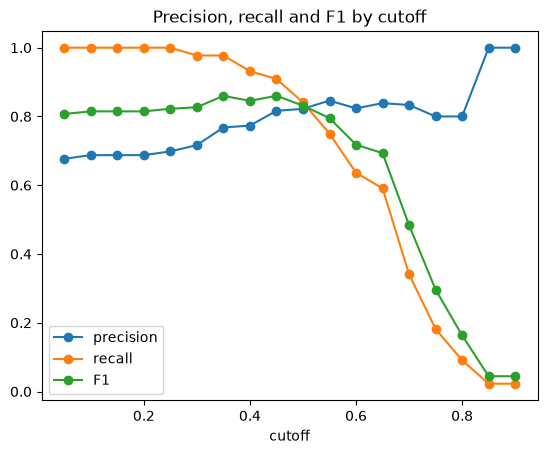

In [21]:
# Each test car's predicted probability of being imported.
probability = logit.predict_proba(X_test)[:, 1]

# Try cutoffs from 0.05 to 0.90 and record precision, recall and F1 at each.
results = []
for cutoff in np.arange(0.05, 0.91, 0.05):
    tagged = (probability >= cutoff).astype(int)
    results.append({'cutoff': round(cutoff, 2),
                    'precision': precision_score(y_test, tagged),
                    'recall': recall_score(y_test, tagged),
                    'F1': f1_score(y_test, tagged)})

results_df = pd.DataFrame(results)
results_df.plot(x='cutoff', y=['precision', 'recall', 'F1'], marker='o', title='Precision, recall and F1 by cutoff')
results_df.sort_values('F1', ascending=False).head(3).round(2)

**Question 8.** Which cutoff balances the two errors best?

**Answer**

Logistic regression gives each car a probability (`predict_proba`), which is what lets us move the cutoff.

At the default cutoff of 0.5, the confusion matrix shows **7 imports missed** (false negatives) and **8 domestic cars tagged "Imported"** (false positives), out of 118 test cars.

| Cutoff | Precision | Recall | F1 | False negatives | False positives |
| --- | --- | --- | --- | --- | --- |
| 0.35 | 0.77 | 0.98 | 0.86 | 1 | 13 |
| **0.45** | **0.82** | **0.91** | **0.86** | **4** | **9** |
| 0.50 | 0.82 | 0.84 | 0.83 | 7 | 8 |
| 0.70 | 0.83 | 0.34 | 0.48 | 29 | 3 |

**The best balance is a cutoff of about 0.45** (F1 0.86; 0.35 is almost tied). F1 is high only when precision *and* recall are both high, so it is the natural "balance the two errors" score. Compared with the default 0.5, it catches 3 more imports for 1 extra false positive. In the plot, lowering the cutoff pushes recall up and precision down, and F1 peaks where neither has collapsed.

### Does PCA help?

**Exercise 9.** Does PCA help the tagger? Run kNN on the principal components instead of the six specs, trying every possible number of components. Compare each with kNN on all six specs, using the k you chose in Exercise 7.

In [22]:
# kNN on all six scaled specs vs. on the first 1 to 6 principal components.
# PCA sits inside the pipeline, so it is learned from each fold's training cars only.
full = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
print('All 6 specs:     ', round(cross_val_score(full, X_specs, y_imp, scoring='accuracy', cv=folds).mean(), 3))

for n in range(1, 7):
    model = make_pipeline(StandardScaler(), PCA(n_components=n), KNeighborsClassifier(n_neighbors=5))
    print(n, 'component(s):  ', round(cross_val_score(model, X_specs, y_imp, scoring='accuracy', cv=folds).mean(), 3))

All 6 specs:      0.847
1 component(s):   0.753
2 component(s):   0.801
3 component(s):   0.806
4 component(s):   0.824
5 component(s):   0.832


6 component(s):   0.847


**Question 9.** Does PCA help here? How many components do you need?

**Answer**

| Inputs to kNN (k = 5) | CV accuracy |
| --- | --- |
| All 6 specs | 0.847 |
| 1 component | 0.753 |
| 2 components | 0.801 |
| 3 components | 0.806 |
| 4 components | 0.824 |
| 5 components | 0.832 |
| 6 components | 0.847 |

**No, PCA does not help here.** Every smaller set of components does worse than the six specs, and accuracy climbs steadily as components are added back. One component loses about 9 points: PC1 says how big and thirsty a car is, but a small Ford and a small Toyota look the same on that axis. The two components that held 92% of the variation still lose about 5 points. The small leftover dimensions are exactly where import and domestic cars differ. With only six inputs there is little to compress, so dropping components mainly costs information.

**All six components score exactly the same as the six specs (0.847).** Keeping every component only *rotates* the scaled data, and a rotation does not change any distance between cars, so kNN finds the same neighbours. PCA can only change the answer by dropping components.

PCA is learned inside each fold, just like the scaler. Learning it from all the cars first would let the test cars shape the model.

# **What this practice covered**

| Exam 1 topic | Where it came up |
| --- | --- |
| Missing values, identifiers, categorical → dummy variables | Exercises 1, 5 |
| Choosing a chart that answers the question; confounding | Exercise 2 |
| Correlation, scaling, explained variance, the component matrix | Exercises 3, 4 |
| Naive baseline, RMSE, R², train/test split | Exercise 5 |
| Why one split is not enough: cross-validation | Exercises 6, 7 |
| kNN: scaling, choosing k | Exercise 7 |
| Accuracy baseline; choosing between models | Exercise 7 |
| Confusion matrix, precision vs. recall, moving the cutoff | Exercise 8 |
| Fit scaling and PCA on training data only; does PCA help a model? | Exercise 9 |